In [53]:
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
from netgen.geom2d import SplineGeometry
"""
der Code simuliert die Kirchhoff-love Gl mit HHJ-methode, nimmt eine 'verworfene' Platte, 
rechnete diese zusammen, speichert diese als *.xyz datei ab und plottet diese
"""

l = 1100 #mm Länge
b = 360 #mm Breite
t  = 3.6     #Dicke [mm]
step = 40           


radius = 35 #mm Radius der Kreise für Auflager

#region GEOMETRIE
shape = MoveTo(0,0).Rectangle(l,b).Face()

shape.edges.name="free"

#circle = Circle((0,0),0.10).Face()
#circle.edges.name="circles"

rect = shape 

#KREISAUFLAGER
auflager_liste = [(radius,radius),(l-radius,b-radius),(radius,b-radius),(l-radius,radius)]

for mittelpunkt in auflager_liste:
    circle = Circle(mittelpunkt,radius).Face()
    circle.edges.name = "dirichlet"
    rect = rect - circle

#KANTENAUFLAGER
# rect.edges.Min(X).name = "dirichlet"
# rect.edges.Max(X).name = "dirichlet"

geo = OCCGeometry(rect,dim=2)

#Draw(rect)
mesh = Mesh(geo.GenerateMesh(maxh=l/40))

mesh.Curve(3)
#Draw(mesh)

#endregion

In [54]:
#region MATERIALKONSTANTEN
E  = 70e6      #Glas ~ N'/mm² Elastizitätsmodul      
"""
UMRECHNUNG (m -> mm)

Einheit Pascal: 1 Pa = 1 N/m² 
Einheit Newton: 1 N = 1 kg*m/s²     - dh müssen auch Newton umrechnen

Definiere:
N' := kg*mm/s²      - in Millimeter!!!!
    -> 1 N = 1000 N'

1 Pa = 1 N/m² = 10e-6 N/mm² = 10e-6 * 10e3 N'/mm² = 10e-3 N'/mm²

Glas hat E-Modul von 70e9 Pa (70 GPa) = 70e9 N/m² = 70e9 * 10^(-3) N'/mm² = 70e6 N'/mm²         #neuer Wert
"""
nu = 0.23       #dimensionslos, also bei m und mm gleich
rho = 2.5e-6   #kg/mm³ Dichte 
"""
Dichte von Glas 2500 kg/m³ = 2.5 * 10e3 kg/m³
1kg/m³ = 1000g/10e9mm³ = 10e(-6)g/mm³
-> 2.5 * 10e3 * 10e(-6) g/mm³ = 2.5 * 10e(-3) g/mm³ = 0.0025 g/mm³

"""

g = 9810     # Erdbeschleunigung mm/s²
"""
Erdbeschleunigung g = 9.81 m/s² = 9810 mm/s²
"""   

q = rho * t * g     #Eigengewicht der Platte punktweise!!! - rechte Seite der PDE, also unser f_PDE

#region FUNKTIONEN für PDE
Db = E*t**3/(12*(1-nu**2))

def D(A):
    return Db *((1-nu)*A+ nu*Trace(A)*Id(2))

def Dinv(A):
    return 1/Db * (1/(1-nu)*A - nu/(1-nu**2)*Trace(A)*Id(2))
#endregion

In [56]:
#region SIMULATION: FUNKTIONENRAUM,SCHWACHE FORM,VISUALISIERUNG
order = 3

V = HDivDiv(mesh, order=order-1,dirichlet="dirichlet")
Q = H1(mesh, order=order, dirichlet="dirichlet")
X = V * Q

(sigma,w),(tau,v)= X.TnT()

n = specialcf.normal(2)

def tang(u):
    return u - (u*n)*n


#schwache Form von Kirchhoff-Love mit Hellan-Herrmann-Johnson-Method
#https://docu.ngsolve.org/ngs24/SaS/Kirchhoff_Love_plate.html

a = BilinearForm(X,symmetric=True)
a += InnerProduct(Dinv(sigma),tau) * dx
a += div(sigma)*Grad(v) * dx
a += div(tau) * Grad(w) * dx
a += - (sigma[n,:] * tang(Grad(v)) + tau[n,:] * tang(Grad(w))  ) * dx(element_boundary=True)
a.Assemble()

L = LinearForm(X)
L += q * v *dx
L.Assemble()

gf_solution = GridFunction(X)
gf_solution.vec.data = a.mat.Inverse(X.FreeDofs(),inverse="") * L.vec

gf_sigma, gf_w = gf_solution.components
#Draw(gf_sigma, mesh,name="sigma")
Draw(gf_w, mesh, name="disp",deformation=True, euler_angles=[-60,5,30])

#endregion

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'euler_angles': […

BaseWebGuiScene

In [59]:
import numpy as np
import inspect


#erzeugt gitter für gewünschte werte
x_points = np.linspace(0,l, step)
y_points = np.linspace(0,b, step)
X, Y = np.meshgrid(x_points, y_points)
#print(x_points)

#speichert (x,y,z) in gravitation_matrix für alle (x,y) in X,Y
gravitation_matrix = np.zeros((step, step),dtype=object)
for i in range(step):
    for j in range(step):
        try:
            z_eintrag = gf_w(X[i, j], Y[i, j])
        except:
            z_eintrag = 0
        gravitation_matrix[i, j] = (float(X[i,j]), float(Y[i,j]), z_eintrag)



#*.xyz file erstellen
filename_gravitation = f"{t}mm_gravitation.xyz"
with open(filename_gravitation, "w") as f:
    for i in range(step):
        for j in range(step):
            x, y, w = gravitation_matrix[i, j]
            f.write(f"{x:.6f}\t{y:.6f}\t{w:.6e}\n")


[   0.           28.20512821   56.41025641   84.61538462  112.82051282
  141.02564103  169.23076923  197.43589744  225.64102564  253.84615385
  282.05128205  310.25641026  338.46153846  366.66666667  394.87179487
  423.07692308  451.28205128  479.48717949  507.69230769  535.8974359
  564.1025641   592.30769231  620.51282051  648.71794872  676.92307692
  705.12820513  733.33333333  761.53846154  789.74358974  817.94871795
  846.15384615  874.35897436  902.56410256  930.76923077  958.97435897
  987.17948718 1015.38461538 1043.58974359 1071.79487179 1100.        ]


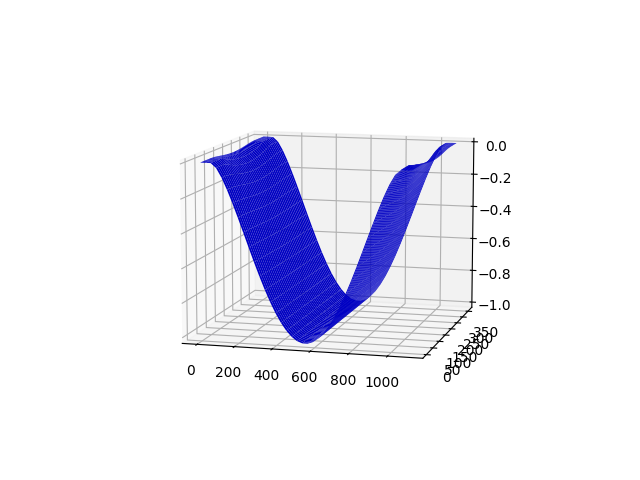

In [58]:
#Plotten

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(threshold=np.inf)

data_GRAV = np.loadtxt(filename_gravitation)

x_GRAV = data_GRAV[:,0]
y_GRAV = data_GRAV[:,1]
z_GRAV = data_GRAV[:,2]

# Raster erzeugen
X = np.unique(x_GRAV)
Y = np.unique(y_GRAV)

X, Y = np.meshgrid(X, Y)
Z_GRAV=z_GRAV.reshape(len(Y), len(X))

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X, Y, Z_GRAV,color="blue")       # gravitation


ax.view_init(elev=10, azim=-75)
plt.show()
